Name ISabelle Maru Shapiro

Labpartner(s)

In [140]:
#import statements go here
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

**For today's lab you need to install the package cartopy**

In [14]:
# you can install packages here in a notebook with pip or conda, 
# or in the anaconda navigator in the environments tab (reccommended)
#pip install cartopy
#conda install cartopy

In [15]:
# I had an old version of cartopy so I had to upgrade:
# pip install --upgrade cartopy

In [141]:
import cartopy.crs as ccrs   #import map styles/types
import cartopy.feature as cfeature  # features such as the ocean, coastlines rivers, etc

# Class 6.2

Today we will finish fiunction sharing and do more plotting

# Warmups 6.2

**W.1** Write some code that generates 15 random integers from 1-100. If the integers are divisible by 2 assign them to list "x" if they are divisible by three, assign them to list "y", if they are neither assign them to list "z". 

In [10]:
random_int = []
x =list()
y = []
z = []

for k in range (0, 15):
    random_int.append(np.random.randint(1,100))


for val in random_int:
    if val%2==0:
        x.append(val)
    elif val%3==0:
        y.append(val)
    else:
        z.append(val)

print(x)
print(y)
print(z)



[26, 34, 24, 28, 90, 40, 96, 14, 60]
[69, 9]
[65, 79, 97, 61]


In [6]:
type(x)

int

In [7]:
random_int = []
a=list()
b =list()
c =list()

for x in range (0, 15):
    random_int.append(np.random.randint(1,100))


for val in random_int:
    if val%2==0:
        a.append(val)
    elif val%3==0:
        b.append(val)
    else:
        c.append(val)

print(a)
print(b)
print(c)


[70, 80, 2, 46, 50, 6, 78, 66]
[57]
[13, 7, 71, 5, 5, 65]


In [8]:
type(a)

list

# Lecture 6.2

### Agenda:

- Show us your functions
- Questions
- cartopy

### Show us your functions (from Lab 5.2) - continued

### Questions

### Cartopy

Let's take the data we used last time and make the plot publication ready

There are a number of differnt map projections available in Cartopy.  
https://cartopy.readthedocs.io/stable/reference/projections.html
Robinson is often used for global maps

C:\Users\isabe\anaconda3\Lib\site-packages\cartopy\io\__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


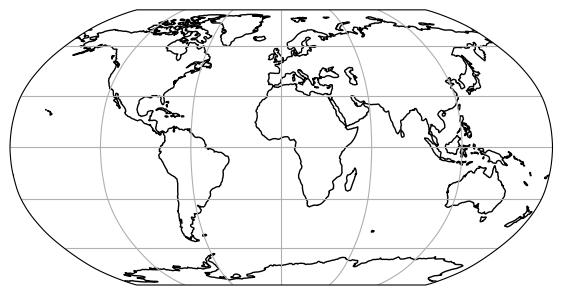

In [17]:
# plot a basic map with no data
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.Robinson())
ax.coastlines(resolution='110m')
ax.gridlines()

When we are plotting ocean data, we like to make the Pacific contiguous, let's rotate

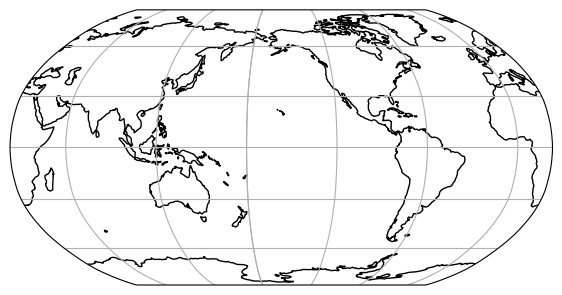

In [26]:
# plot a basic map with no data, rotated
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.Robinson(central_longitude = 203)) # this rotates the map to 203 degrees East
ax.coastlines(resolution='110m')
ax.gridlines()

Or we can rotate it so that it cuts through Indonesia (not good for mangrove or coral work)

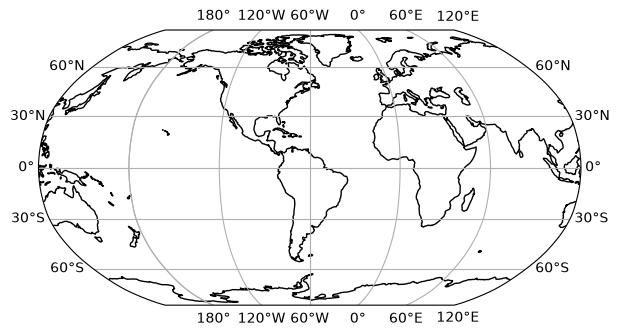

In [21]:
# plot a basic map with no data, rotated
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.Robinson(central_longitude = -60))
# -60 (60 W) is the same as 300 E (360 degrees in total 360-60W = 300E)
ax.coastlines(resolution='110m')
ax.gridlines(draw_labels=True) # let's add some labels



Let's try some different map projections

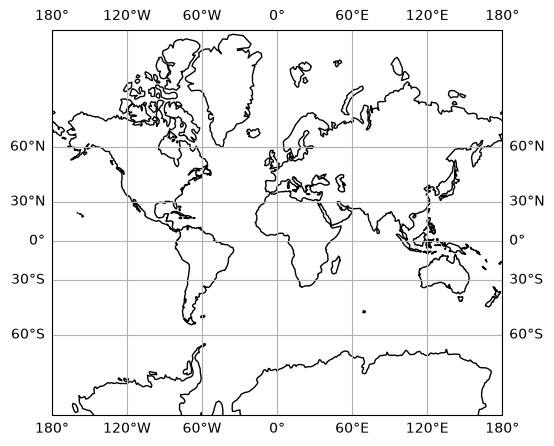

In [22]:
# plot a basic map with no data
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.Mercator()) # different map projection
ax.coastlines(resolution='110m')
ax.gridlines(draw_labels=True)

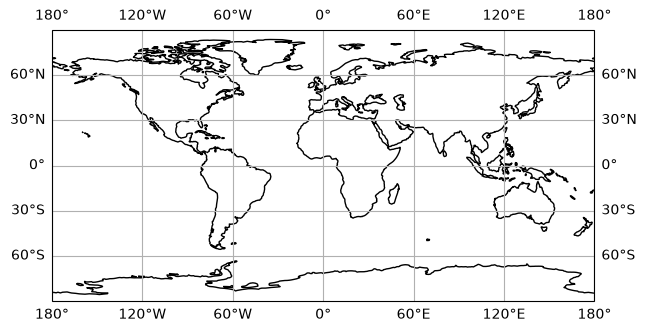

In [27]:
# plot a basic map with no data
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines(resolution='110m')
ax.gridlines(draw_labels=True)


How do I zoom in?

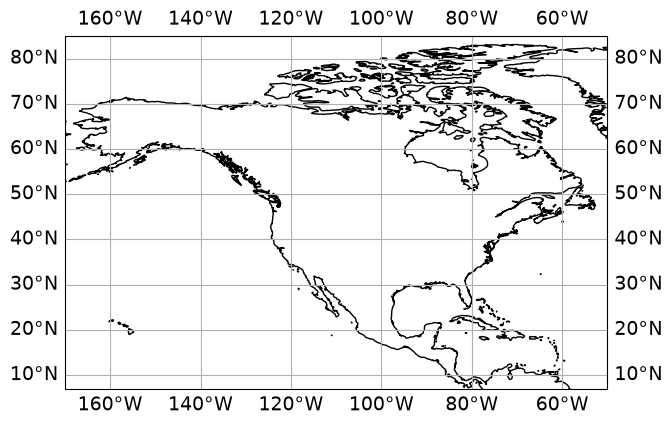

In [139]:
# let's zoom in to S Asia
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-170,-50,80,7 ]) # set the limits of the plot: lon min, lon max, lat min, lat max
ax.coastlines(resolution='50m')  # zoom in: need better resolution
ax.gridlines(draw_labels=True)


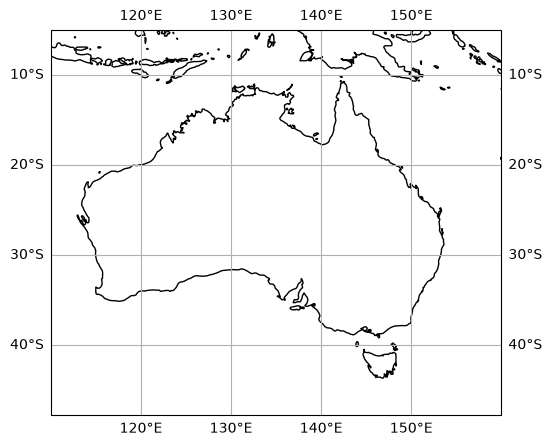

In [39]:
# make a plot of Australia

plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([110,160,-5,-45]) # set the limits of the plot
ax.coastlines(resolution='50m')
ax.gridlines(draw_labels=True)



#### Moving back to the Gulf of Mexico, we want to set the lat and lon range to match our HYCOM data. How do we find this?

In [115]:
#insert path or url to file here
# download from the internet:
link = "https://tds.hycom.org/thredds/dodsC/datasets/GOMe0.04/expt_03.9/data/archive/2026/039_archv.2026_001_00_2d.nc"

In [116]:
gom_data = xr.open_dataset(link, decode_times=False)

In [117]:
gom_data

<xarray.Dataset> Size: 5MB
Dimensions:                (MT: 1, Latitude: 385, Longitude: 525)
Coordinates:
  * MT                     (MT) float64 8B 4.566e+04
    Date                   (MT) float64 8B ...
  * Latitude               (Latitude) float32 2kB 18.09 18.13 ... 31.93 31.96
  * Longitude              (Longitude) float32 2kB -98.0 -97.96 ... -77.04
Data variables:
    surface_e_stress       (MT, Latitude, Longitude) float32 808kB ...
    surface_n_stress       (MT, Latitude, Longitude) float32 808kB ...
    ssh                    (MT, Latitude, Longitude) float32 808kB ...
    u_barotropic_velocity  (MT, Latitude, Longitude) float32 808kB ...
    v_barotropic_velocity  (MT, Latitude, Longitude) float32 808kB ...
    mixed_layer_thickness  (MT, Latitude, Longitude) float32 808kB ...
Attributes:
    Conventions:                     CF-1.6
    title:                           HYCOM
    source:                          HYCOM archive file
    experiment:                      01.4
    history:                         archv2ncdf2d
    comment:                         p-grid
    DODS_EXTRA.Unlimited_Dimension:  MT

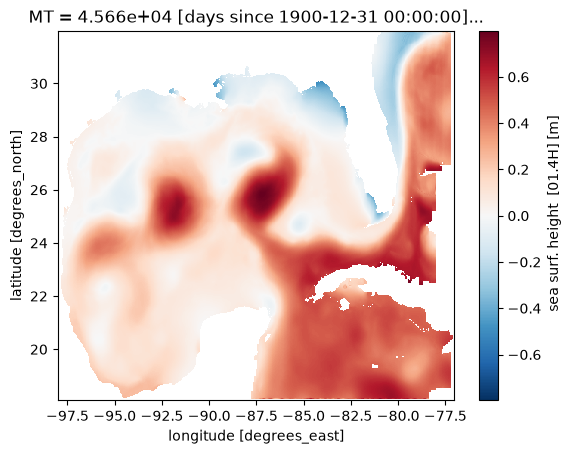

In [67]:
# let's remember what our data looked like, pick a variable to plot

gom_data.ssh.plot()

I'm going to get the max and min of the lat and lon to help me plot the data

In [68]:
lat_min = gom_data.Latitude.min()
print(lat_min)

<xarray.DataArray 'Latitude' ()> Size: 4B
array(18.091648, dtype=float32)
Attributes:
    standard_name:  latitude
    units:          degrees_north
    axis:           Y


In [69]:
lat_max = gom_data.Latitude.max()
print(lat_max)

<xarray.DataArray 'Latitude' ()> Size: 4B
array(31.960648, dtype=float32)
Attributes:
    standard_name:  latitude
    units:          degrees_north
    axis:           Y


In [70]:
lon_min = gom_data.Longitude.min()
print(lon_min)

<xarray.DataArray 'Longitude' ()> Size: 4B
array(-98., dtype=float32)
Attributes:
    standard_name:  longitude
    units:          degrees_east
    point_spacing:  even
    axis:           X


In [71]:
lon_max = gom_data.Longitude.max()
print(lon_max)

<xarray.DataArray 'Longitude' ()> Size: 4B
array(-77.03998, dtype=float32)
Attributes:
    standard_name:  longitude
    units:          degrees_east
    point_spacing:  even
    axis:           X


Now I can use them below

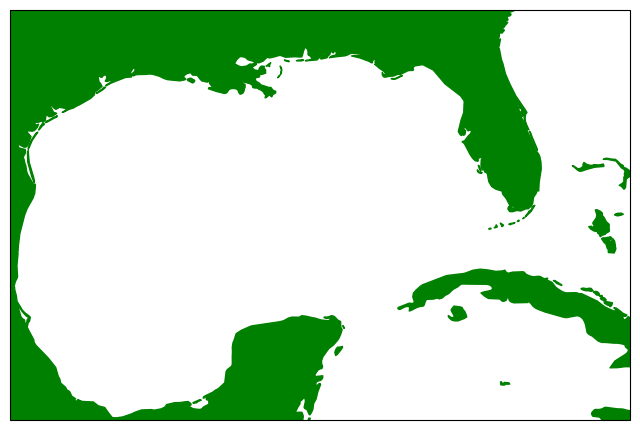

In [72]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent( [lon_min, lon_max, lat_min, lat_max]) 
# note the seqence of arguments for set_extent: x1, x2, y1, y2

#Sets the land onto the projection with the right color and scale
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='green',
                                    facecolor='green')
# you can use named colors: https://matplotlib.org/stable/gallery/color/named_colors.html
# or with other methods: https://matplotlib.org/stable/users/explain/colors/colors.html

ax.add_feature(land_50m)

#### Let's make the land color a bit lighter gray

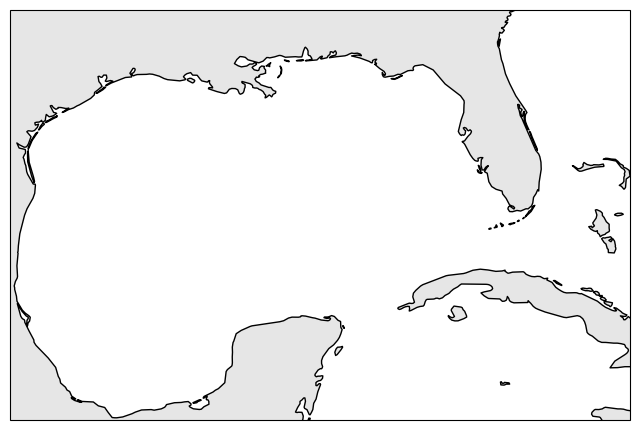

In [73]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent( [lon_min, lon_max, lat_min, lat_max]) 
# note the seqence of arguments for set_extent: x1, x2, y1, y2

#Sets the land onto the projection with the right color and scale
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.9') # 0 is black and 1 is white
# you can use named colors: https://matplotlib.org/stable/gallery/color/named_colors.html
# or with other methods: https://matplotlib.org/stable/users/explain/colors/colors.html

ax.add_feature(land_50m)

In [74]:
var = gom_data.ssh[0,:,:]
var

<xarray.DataArray 'ssh' (Latitude: 385, Longitude: 525)> Size: 808kB
[202125 values with dtype=float32]
Coordinates:
  * Latitude   (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude  (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
    MT         float64 8B 4.566e+04
    Date       float64 8B ...
Attributes:
    standard_name:  sea_surface_elevation
    units:          m
    valid_range:    [-0.504511   0.7986358]
    long_name:       sea surf. height  [01.4H]
    _ChunkSizes:    [  1 385 525]

#### Now let's add some data

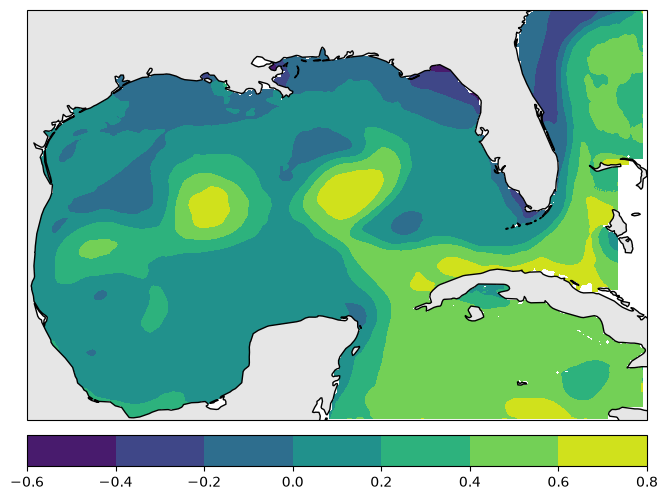

In [87]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent( [lon_min, lon_max, lat_min, lat_max]) 

# Sets the land onto the projection with the right color and scale
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.9')
ax.add_feature(land_50m)

# let's fill in the following:
x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.ssh[0,:,:]

# Contours the data on tho the map projection
p = ax.contourf(x, y, var, transform=ccrs.PlateCarree()) # projection is needed in every plot call

# Creates colorbar based on the contour. This allows us to get a quick look at our data range 
# before we start formatting the figure 
cbar = plt.colorbar(p, orientation='horizontal', pad=0.02)


#### Try taking out the options for the colorbar, what happens? What does "pad" do?

#### What is the range of our data?

In [88]:
print(var.max())

<xarray.DataArray 'ssh' ()> Size: 4B
array(0.7986358, dtype=float32)
Coordinates:
    MT       float64 8B 4.566e+04
    Date     float64 8B ...
Attributes:
    standard_name:  sea_surface_elevation
    units:          m
    valid_range:    [-0.504511   0.7986358]
    long_name:       sea surf. height  [01.4H]
    _ChunkSizes:    [  1 385 525]


In [89]:
print(var.min())

<xarray.DataArray 'ssh' ()> Size: 4B
array(-0.504511, dtype=float32)
Coordinates:
    MT       float64 8B 4.566e+04
    Date     float64 8B ...
Attributes:
    standard_name:  sea_surface_elevation
    units:          m
    valid_range:    [-0.504511   0.7986358]
    long_name:       sea surf. height  [01.4H]
    _ChunkSizes:    [  1 385 525]


#### Let's set the countour levels to match our data range. I'm also going to change the colormap
See https://matplotlib.org/stable/users/explain/colors/colormaps.html
Note you can reverse any colormap by appending '_r' to the name

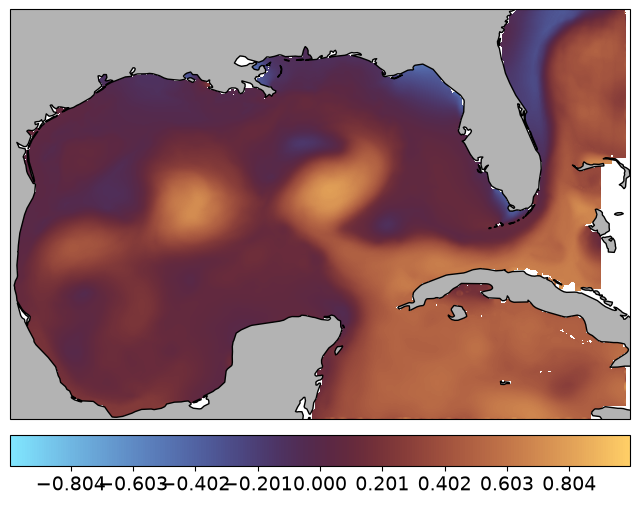

In [126]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([lon_min, lon_max, lat_min, lat_max]) 

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.7')
ax.add_feature(land_50m)

x = gom_data.Longitude
y = gom_data.Latitude
var =  gom_data.ssh[0,:,:]

# let's fill in the range here:
step = np.arange(-1, 1.001, 0.001)  #start, stop, step
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'managua_r',   #red --> blue but want to reverse it so do _r
                    levels = step) # projection is needed in every plot call

cbar = plt.colorbar(p, orientation='horizontal', pad=0.02)


#### Okay, now let's add some labels

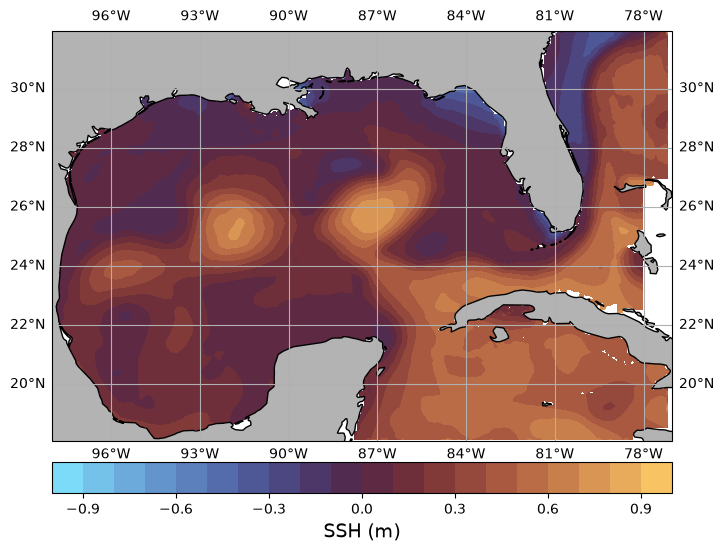

In [106]:
# copy in previous code here
# I'm also going to cut out the white bits at right by adjusting lon_max

fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([lon_min, lon_max, lat_min, lat_max]) 

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.7')
ax.add_feature(land_50m)

x = gom_data.Longitude
y = gom_data.Latitude
var =  gom_data.ssh[0,:,:]

# let's fill in the range here:
step = np.arange(-1, 1.1, 0.1)  #start, stop, step
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'managua_r',   #red --> blue but want to reverse it so do _r
                    levels = step) # projection is needed in every plot call

cbar = plt.colorbar(p, orientation='horizontal', pad=0.028)


cbar.set_label("SSH" +' (m)', size = 14)

ax.gridlines(draw_labels=True)


#### These labels are too small for what I want. I need them to be much bigger.

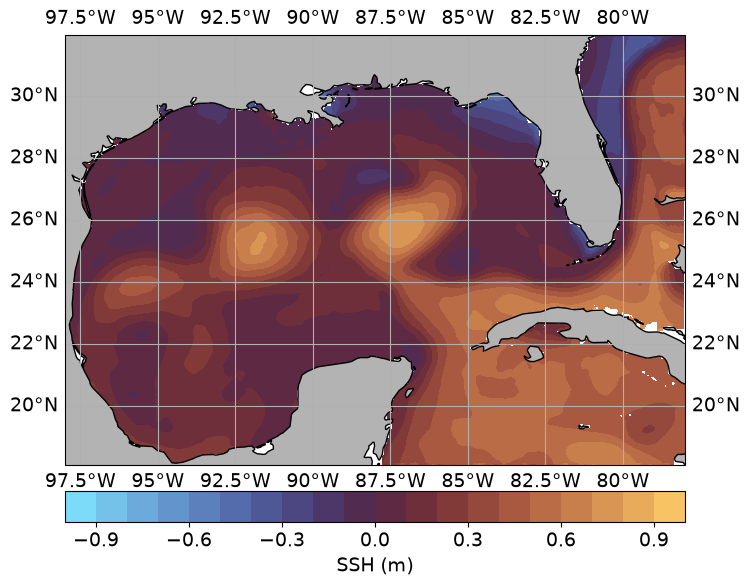

In [112]:
#Note we can easily make the lat/lon and colorbar font size bigger by adjusting the matplotlib parameters, 
# which I introduced last time
import matplotlib as mpl

fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([lon_min, -78, lat_min, lat_max]) 

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.7')
ax.add_feature(land_50m)

x = gom_data.Longitude
y = gom_data.Latitude
var =  gom_data.ssh[0,:,:]

# let's fill in the range here:
step = np.arange(-1, 1.1, 0.1)  #start, stop, step
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'managua_r',   #red --> blue but want to reverse it so do _r
                    levels = step) # projection is needed in every plot call

cbar = plt.colorbar(p, orientation='horizontal', pad=0.033)


cbar.set_label("SSH" +' (m)', size = 14)

ax.gridlines(draw_labels=True)

mpl.rcParams['font.size'] = 14

In [ ]:
#exact same code as before


#### Not bad

## Lab 6.2

**E.0** Finish Lab 6.1 if you haven't already.

**E.1** Complete Introduction to Data Visualization with Matplotlib Chapters 3-4. Let me know if this feels like a good pace

In [ ]:



Ax.set_xticklabels (dataframe.index, rotation = 90)
Stacked barchart:
ax.bar(dataframe.index, dataframe[“column”], bottom = dataframe[“column on bottom”])
ax.bar(df.index, df[“column”], bottom = df[“column on bottom”] + df[column in middle”], label = “column”)

ax.legend()

ax.hist(df[“column”], label = “label”, bins = #) ←or bins = [150, 160, 170, 180]… to customize bin boundaries 

^ Add histtype = “step” to remove color 


ax.bar(“Label”, df[“Column”].mean(), yerr = df[“column”].stf()) ←add an standard deviation bar to average bar 

ax.errorbar(df[“x colum”], df[“y column”], yerr = df[“standard dev colum”]) ← add vertical markers to plot 


ax.boxplot([df[“column”], df[“another column”]])
ax.set_xticklabels([“column label”,”column label”])


ax.scatter(df[“x asix column”], df[“y axis”], color = “red”, label = “label”)
ax.scatter(df[“x asix column”], df[“y axis”], c= df.index, label = “label”) ←here index is a time data so making color = time you get a gradient of points along the time 


Subset = df[“index start” : “index end”] ←like time series indexing 


plt.style.use(“ggplot”) ← change plot style (add before the fig,ax line)

plt.style.use(“default”) ←reset to default style 


fig.savefig(“fig name.jpg”, qulity = number less than 95) ← also can use dpi=300 to get high uality image 

fig.set_size_inches([5,3]) ← set aspect ratio 


X = df[“column”].unique() ← unqiue values in a column 

For x in df:
	Newdf = df[df[column] == x]
	


**E.2** Make notes for yourself on progamming tecniques and commands you learned in the lecture and datacamp chapter above, including examples, comments and explainitory text. You can do this here or in a separate notebook that you link to here. Basically, you are making a cheat sheet for yourself.

In [127]:
gom_data.u_barotropic_velocity

<xarray.DataArray 'u_barotropic_velocity' (MT: 1, Latitude: 385, Longitude: 525)> Size: 808kB
[202125 values with dtype=float32]
Coordinates:
  * MT         (MT) float64 8B 4.566e+04
    Date       (MT) float64 8B ...
  * Latitude   (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude  (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
Attributes:
    standard_name:  barotropic_eastward_sea_water_velocity
    units:          m/s
    valid_range:    [-0.5779634  1.1159977]
    long_name:          baro. u-vel.   [01.4H]
    _ChunkSizes:    [  1 385 525]

**E.3** Make a plot of a different variable for the HYCOM data. Play around with colormaps and contourlines to make it your own. Post your plot on the class slack #programming channel

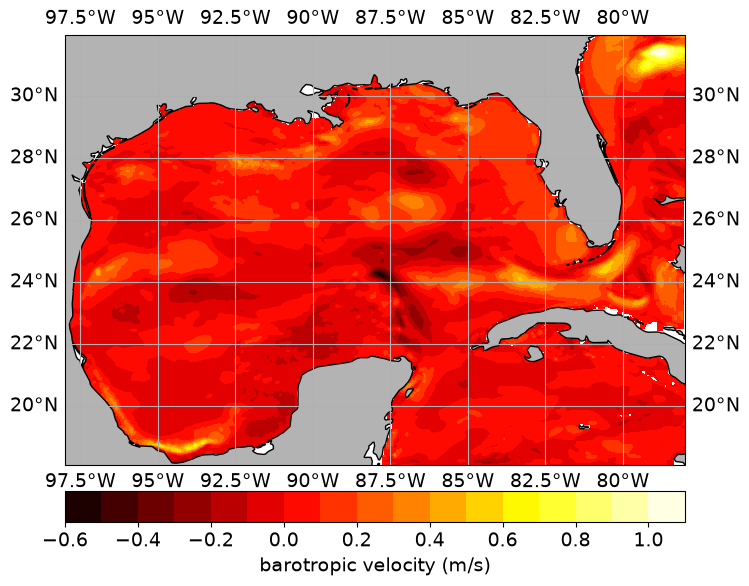

In [132]:



#Note we can easily make the lat/lon and colorbar font size bigger by adjusting the matplotlib parameters, 
# which I introduced last time
import matplotlib as mpl

fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([lon_min, -78, lat_min, lat_max]) 

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.7')
ax.add_feature(land_50m)

x = gom_data.Longitude
y = gom_data.Latitude


var =  gom_data.u_barotropic_velocity[0,:,:]

# let's fill in the range here:
step = np.arange(-.6, 1.2, 0.1)  #start, stop, step
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'hot',   #red --> blue but want to reverse it so do _r
                    levels = step) # projection is needed in every plot call

cbar = plt.colorbar(p, orientation='horizontal', pad=0.033)


cbar.set_label("barotropic velocity" +' (m/s)', size = 14)

ax.gridlines(draw_labels=True)

mpl.rcParams['font.size'] = 14

### This week's project:

#### Note you might want to restart your kernel at this point to dump all the hycom data from memory. Just reload the packages you need

**E.4** Download some data from the ISIMIP data archive (https://data.isimip.org/) and plot it using cartopy. ISIMIP provides bias-corrected data for past and future climate simulations used for impacts studies world wide. Let's start with some maximum atmospheric surface temperature data in the historical period (1850-2014 for CMIP6). We want climate forcing data for ISIMIP3b, which are the lastest (CMIP6) climate projections. 

* https://data.isimip.org/search/tree/ISIMIP3b/InputData/climate/
* Click atmopsheric forcing
* Click GFDL... This is one of NOAA-GFDL's climate models (ESM4)
* Click historical

All of the variable names are in CMIP lingo. Sadly, there is no easy cheat sheet. But you want tas, which is "temperature of air at surface". Let's use the tasmax, the maximum daily surface air temperature
* Click tasmax
* Click files to see all the available files.
  
Here you have a choice, you can download an etire file (note the size) or you can use the "configure download" button, which has subsetting by space or country, as well as time opitons. You can click on a file name to see more info.
* Click on "download file" for the 1851-1860 file. Just grab the whole file, it will take a minute to download.
* Load up the data into xarray and plot the maximum of this dataset (so max over the decade for each gridcell. You just use a max function for this, no loops needed).
* Plot using cartopy to make it pretty. Put some sensible lables on it, etc. Maybe add some country boundaries.

In [158]:
#load in data: my computer couldnt even comprehend the idea of downloadind full earth, so zoomed in on north america
nAmerica = xr.open_dataset("Historical_climate.nc", decode_times=False)

In [163]:
nAmerica.tasmax

<xarray.DataArray 'tasmax' (time: 3653, lat: 146, lon: 240)> Size: 512MB
array([[[247.13089, 247.13562, ..., 246.08405, 245.61644],
        [246.29286, 246.28107, ..., 246.82874, 246.4301 ],
        ...,
        [299.8046 , 299.73505, ..., 298.77686, 298.7343 ],
        [299.80804, 299.76636, ..., 298.73514, 298.66653]],

       [[250.31926, 250.11072, ..., 246.88852, 246.58093],
        [249.4963 , 249.25864, ..., 246.99397, 246.74553],
        ...,
        [299.80423, 299.71176, ..., 298.84073, 298.76642],
        [299.86105, 299.81406, ..., 298.98227, 299.0092 ]],

       ...,

       [[242.49672, 242.83969, ..., 231.40297, 230.99217],
        [242.88863, 242.98001, ..., 230.78537, 230.31682],
        ...,
        [299.6956 , 299.53027, ..., 299.16754, 299.18036],
        [299.6441 , 299.56418, ..., 299.1864 , 299.1851 ]],

       [[245.6504 , 245.48383, ..., 229.57504, 229.1998 ],
        [244.9089 , 244.80971, ..., 228.90376, 228.55803],
        ...,
        [299.4044 , 299.31137, ..., 299.23483, 299.03873],
        [299.2336 , 299.2211 , ..., 299.0969 , 299.0108 ]]],
      shape=(3653, 146, 240), dtype=float32)
Coordinates:
  * time     (time) float64 29kB 0.0 1.0 2.0 ... 3.65e+03 3.651e+03 3.652e+03
  * lat      (lat) float64 1kB 79.75 79.25 78.75 78.25 ... 8.75 8.25 7.75 7.25
  * lon      (lon) float64 2kB -169.8 -169.2 -168.8 ... -51.25 -50.75 -50.25
Attributes:
    standard_name:  air_temperature
    long_name:      Daily Maximum Near-Surface Air Temperature
    units:          K

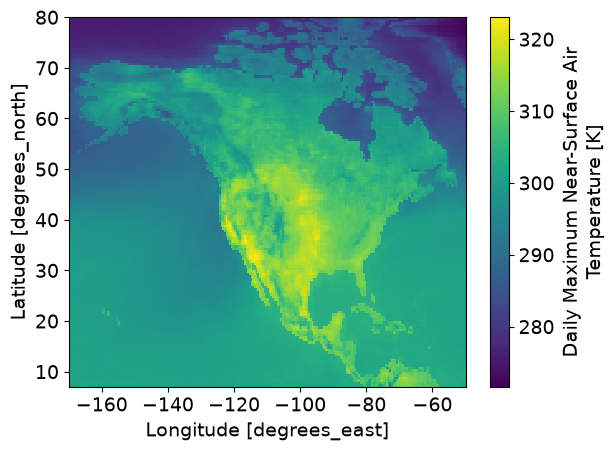

In [160]:
nAmerica["tasmax"].max(dim="time").plot()

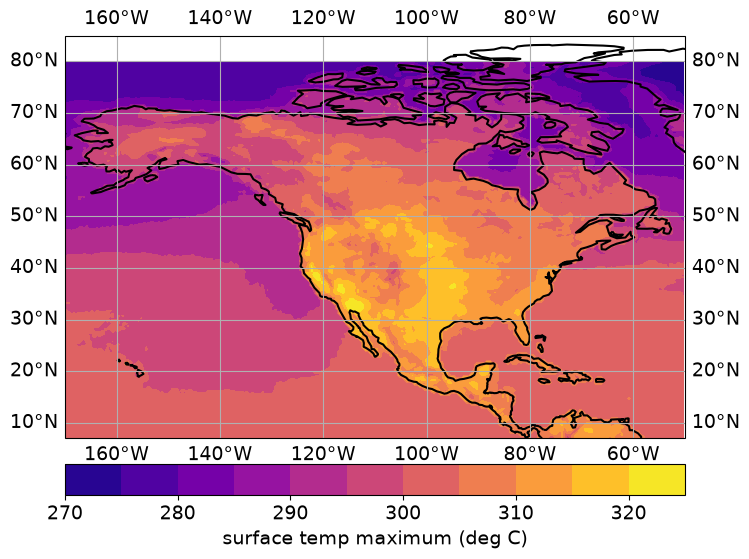

In [173]:
import matplotlib as mpl

fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([-170, -50, 7, 80]) 

#land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                #    edgecolor='black',)
#ax.add_feature(land_50m)
ax.coastlines (resolution='110m', linewidth=1.5, edgecolor='black')
x = nAmerica.lon
y = nAmerica.lat


var =  nAmerica["tasmax"].max(dim = "time")

# let's fill in the range here:
step = np.arange(270, 330, 5)  #start, stop, step
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'plasma',   #red --> blue but want to reverse it so do _r
                    levels = step) # projection is needed in every plot call

cbar = plt.colorbar(p, orientation='horizontal', pad=0.033)


cbar.set_label("surface temp maximum" +' (deg C)', size = 14)

ax.gridlines(draw_labels=True)

mpl.rcParams['font.size'] = 14

**E.5** Now make a second plot using ISIMP data for a future climate projection. Following the same steps as above, get the GFDL tasmax data for the future climate scenario SSP3-7.0 (higher emissions scenario) for 2051-2060. Again, calculate the maximum at each gridpoint for this data set. This is the future maximum daily temperature for that decade. Make your plot nice.

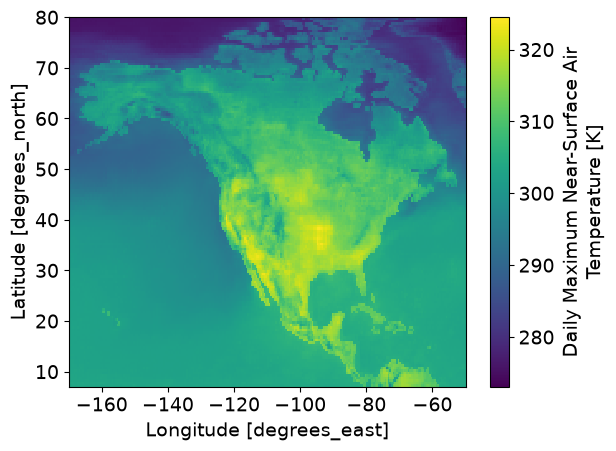

In [156]:
nAmericaFuture = xr.open_dataset("Future_predictions.nc", decode_times=False)
nAmericaFuture["tasmax"].max(dim="time").plot()

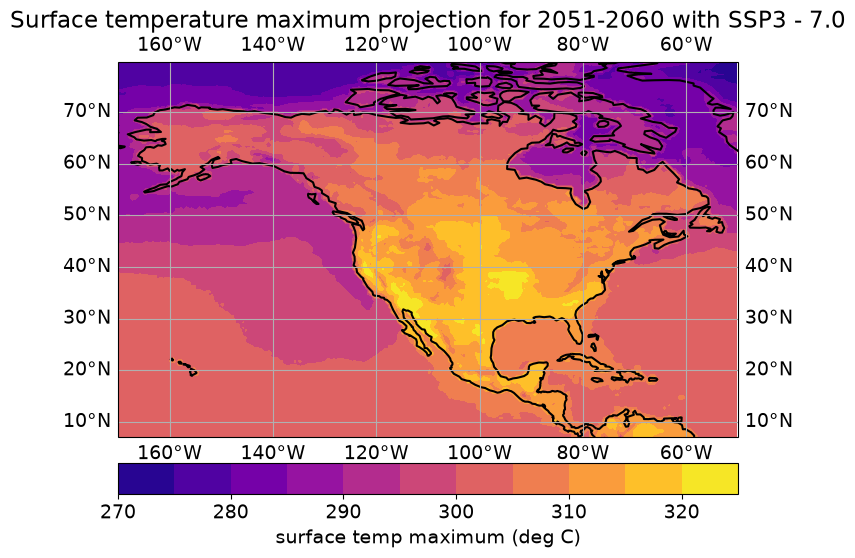

In [199]:
import matplotlib as mpl

fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([-170, -50, 7, 70]) 

#land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                #    edgecolor='black',)
#ax.add_feature(land_50m)
ax.coastlines (resolution='110m', linewidth=1.5, edgecolor='black')
x = nAmericaFuture.lon
y = nAmericaFuture.lat


var =  nAmericaFuture["tasmax"].max(dim = "time")

# let's fill in the range here:
step = np.arange(270, 330, 5)  #start, stop, step
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'plasma',   #red --> blue but want to reverse it so do _r
                    levels = step) # projection is needed in every plot call

cbar = plt.colorbar(p, orientation='horizontal', pad=0.033)


cbar.set_label("surface temp maximum" +' (deg C)', size = 14)

ax.gridlines(draw_labels=True)
ax.set_title("Surface temperature maximum projection for 2051-2060 with SSP3 - 7.0")

mpl.rcParams['font.size'] = 14

**E.6** Now plot the anomaly between the two, 2050's - 1850's. Use a diverging colormap (light in the middle), centered on zero. What is the outlook for your country of orgin? Answer in full sentances with specific numbers.

In [182]:
Future =  nAmericaFuture["tasmax"].max(dim = "time")
Historic =  nAmerica["tasmax"].max(dim = "time")

Anomaly = Future - Historic 

Anomaly

<xarray.DataArray 'tasmax' (lat: 146, lon: 240)> Size: 140kB
array([[ 0.08148193, -0.04125977,  0.06332397, ...,  0.532959  ,
         0.6116638 ,  0.47451782],
       [ 0.00857544, -0.0093689 , -0.03686523, ...,  1.574707  ,
         1.6154785 ,  1.4450073 ],
       [ 0.13476562,  0.14437866,  0.2347107 , ...,  1.1458435 ,
         1.3000488 ,  1.3051453 ],
       ...,
       [ 1.4506226 ,  1.5377808 ,  1.7585144 , ...,  1.9039612 ,
         1.4691162 ,  1.3151245 ],
       [ 1.7549438 ,  1.943634  ,  2.0749207 , ...,  1.6796265 ,
         1.7811279 ,  1.8352356 ],
       [ 1.8251648 ,  1.7208252 ,  1.842865  , ...,  1.7911072 ,
         1.839447  ,  1.7910767 ]], shape=(146, 240), dtype=float32)
Coordinates:
  * lat      (lat) float64 1kB 79.75 79.25 78.75 78.25 ... 8.75 8.25 7.75 7.25
  * lon      (lon) float64 2kB -169.8 -169.2 -168.8 ... -51.25 -50.75 -50.25
Attributes:
    standard_name:  air_temperature
    long_name:      Daily Maximum Near-Surface Air Temperature
    units:          K

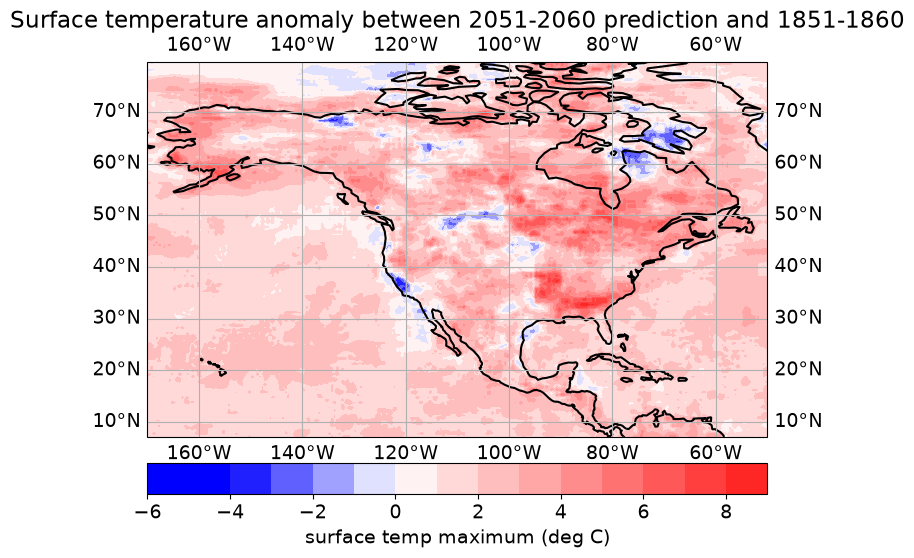

In [210]:
import matplotlib as mpl
import matplotlib.colors as colors
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([-170, -50, 7, 70]) 

#land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                #    edgecolor='black',)
#ax.add_feature(land_50m)
ax.coastlines (resolution='110m', linewidth=1.5, edgecolor='black')
x = Anomaly.lon
y = Anomaly.lat


#var =  Anomaly["tasmax"].max(dim = "time")
middle = colors.TwoSlopeNorm(vcenter=0.0, vmin = -4, vmax = 10)
# let's fill in the range here:
step = np.arange(-6, 10, 1)  #start, stop, step
p = ax.contourf(x, y,Anomaly, transform=ccrs.PlateCarree(), cmap = 'bwr', norm = middle, levels = step)

cbar = plt.colorbar(p, orientation='horizontal', pad=0.033)


cbar.set_label("surface temp maximum" +' (deg C)', size = 14)

ax.gridlines(draw_labels=True)
ax.set_title("Surface temperature anomaly between 2051-2060 prediction and 1851-1860")

mpl.rcParams['font.size'] = 14

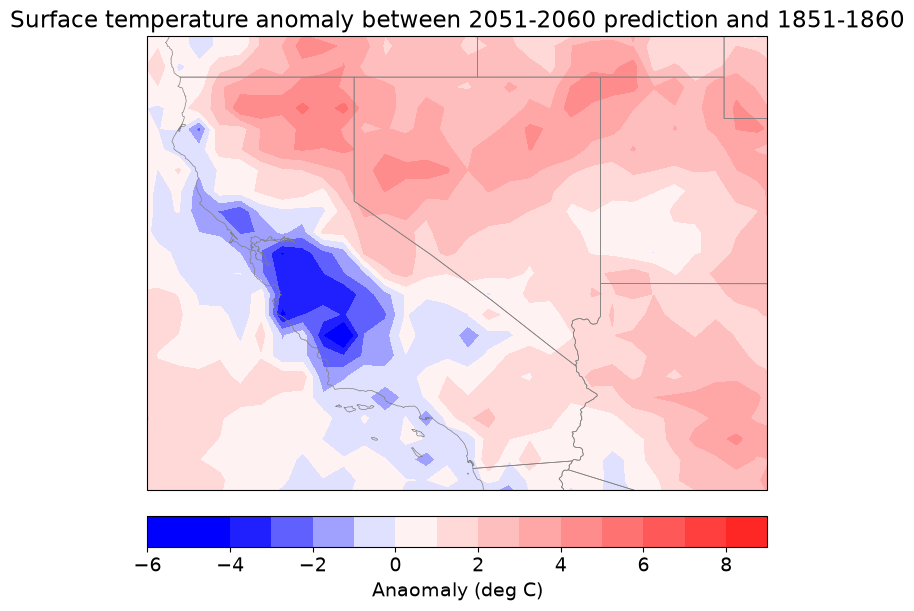

In [208]:
import matplotlib as mpl
import matplotlib.colors as colors
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([-125, -110, 32, 43]) 

#land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                #    edgecolor='black',)
#ax.add_feature(land_50m)
#ax.coastlines (resolution='110m', linewidth=1.5, edgecolor='black')
ax.add_feature(cfeature.STATES, edgecolor="gray", linewidth=0.5)


x = Anomaly.lon
y = Anomaly.lat


#var =  Anomaly["tasmax"].max(dim = "time")
middle = colors.TwoSlopeNorm(vcenter=0.0, vmin = -4, vmax = 10)
# let's fill in the range here:
step = np.arange(-6, 10, 1)  #start, stop, step
p = ax.contourf(x, y,Anomaly, transform=ccrs.PlateCarree(), cmap = 'bwr', norm = middle, levels = step)

cbar = plt.colorbar(p, orientation='horizontal', pad=0.033)


cbar.set_label("Anaomaly" +' (deg C)', size = 14)

#ax.gridlines(draw_labels=True)
ax.set_title("Surface temperature anomaly between 2051-2060 prediction and 1851-1860")

mpl.rcParams['font.size'] = 14

The outlook for the USA on average is a increase in temperature by quite a bit. In the South and east coast the temperature might increase more than 7 degrees, and most of the USA is somewhere about a 2 to 4 degree increase. There are a couple spots that do decrease in temperature, including a large part of california.  There's a small spot close tot the bottom of the central valley that has a -6 degree anomaly prediction, and most of the bay has a nagative anomaly predition.  Northern california will increase in temperature, however, by up to 5 or 6 dgerees. 

**E.7** How could you potentially use this kind of data (future climate projections) in your research? Do some brainstorming. Write down your thoughts here.

future climate projects could be helpful for my research to show how the areas i'm looking at might change in the future.  My research doesn't really involve time series right now so the future climate projections wouldn't be super helpful for the final product but they could be useful for understanding the area generally.  If I could make a map using pCO2 or something instead of temperature that could also be helpful.  I could see how the inverse of this could also be helpful if I could look at what the ocean looked like a long time ago to an compare that to what I cam seeing in a sediment core etc.  